In [43]:
import pandas as pd


In [44]:
# data import
df = pd.read_csv("stroke_data.csv") 

In [45]:
# printing first 10 rows
df.head(n=10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [46]:
# retrieving info about acquired dataframe
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [47]:
# dataset is imbalanced 

print(df['stroke'].value_counts())

stroke
0    4861
1     249
Name: count, dtype: int64


In [49]:
# prinitng basic statistical data
df.describe()


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [50]:
import matplotlib.pyplot as plt

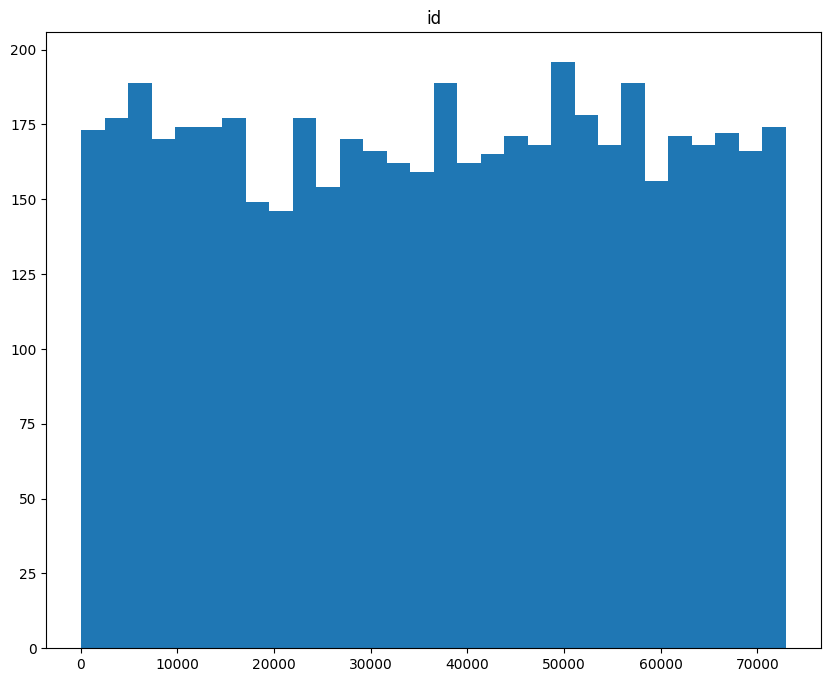

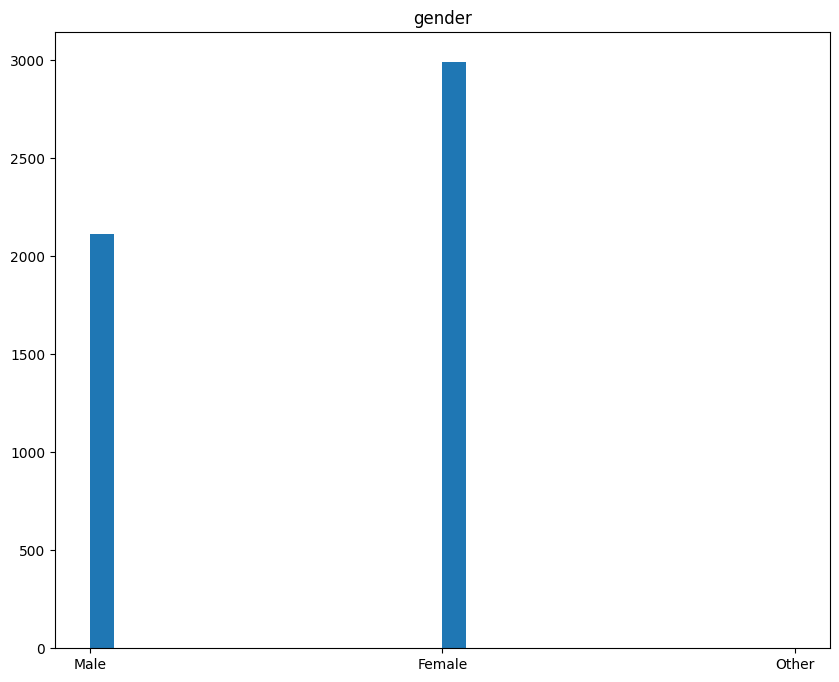

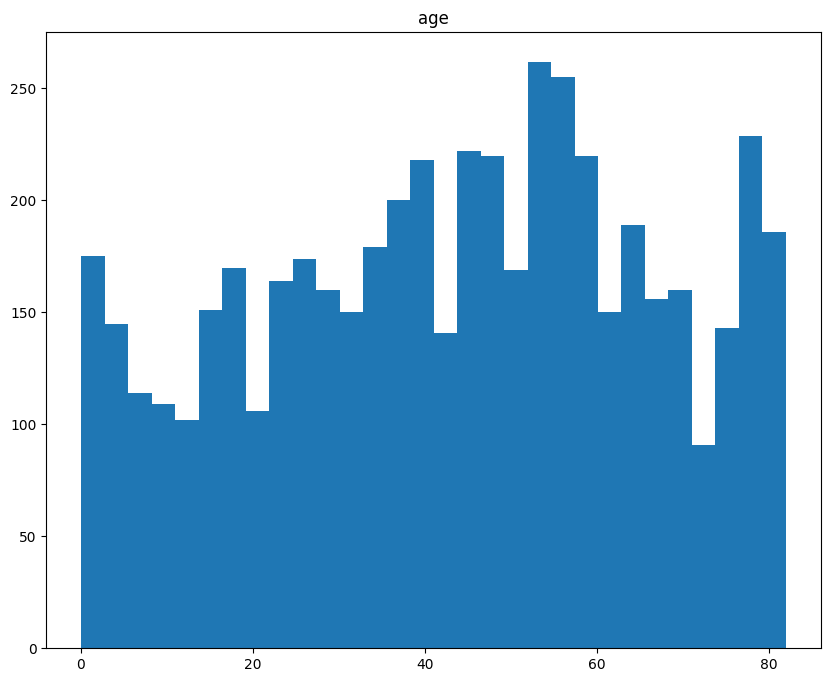

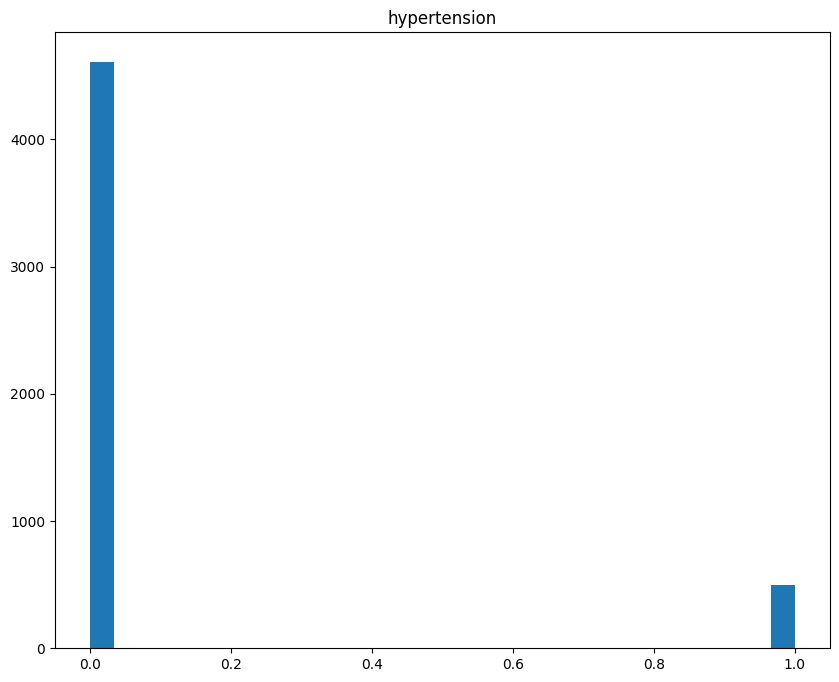

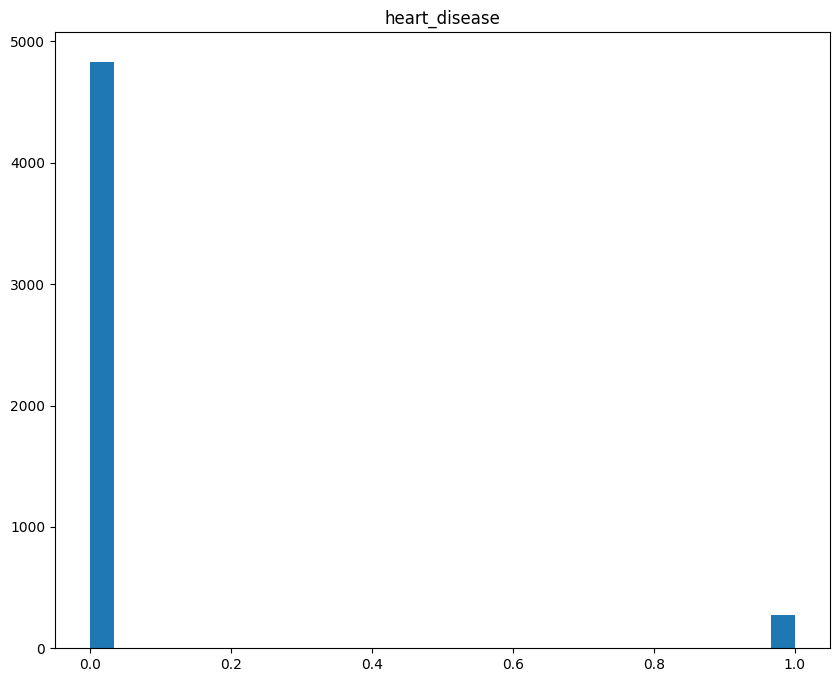

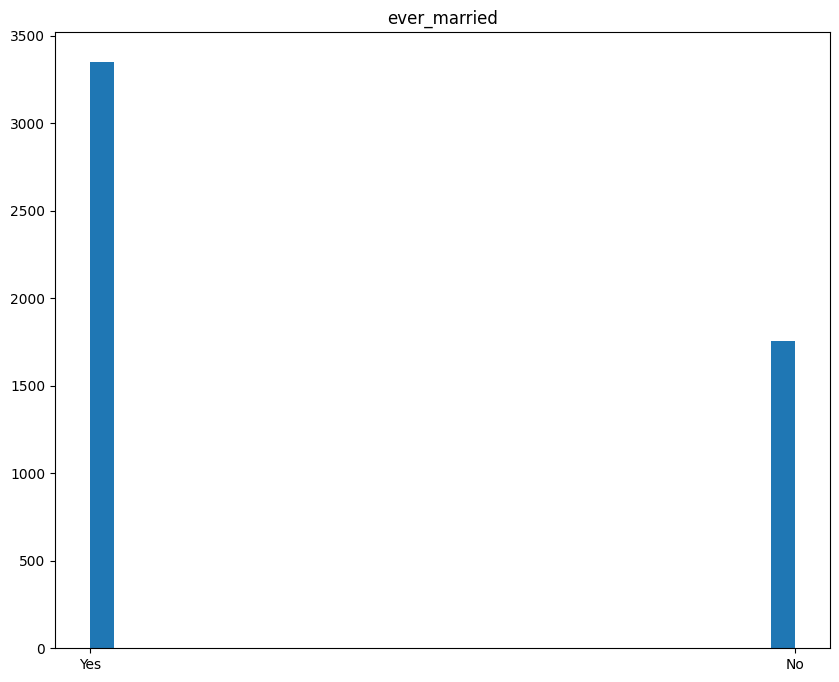

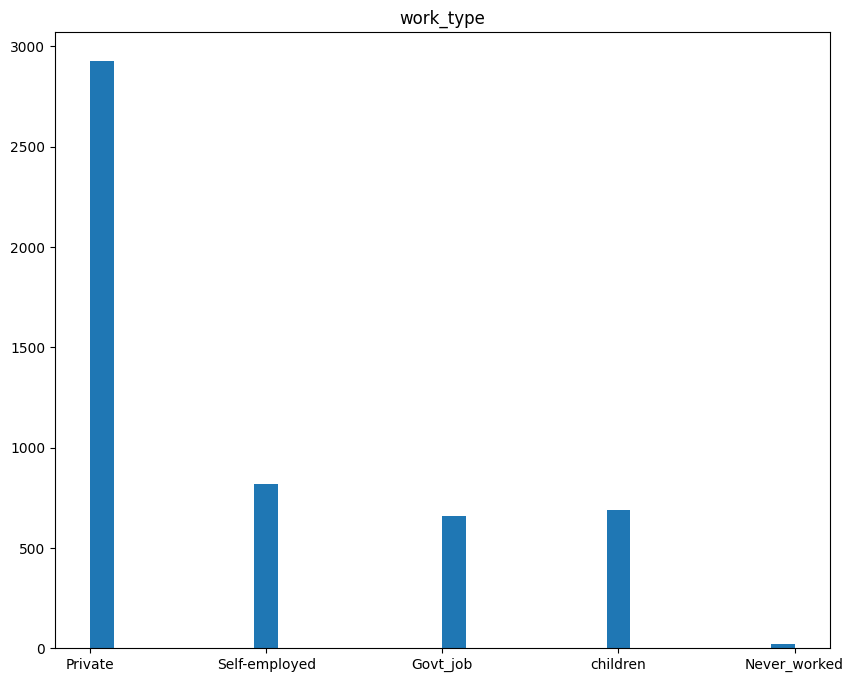

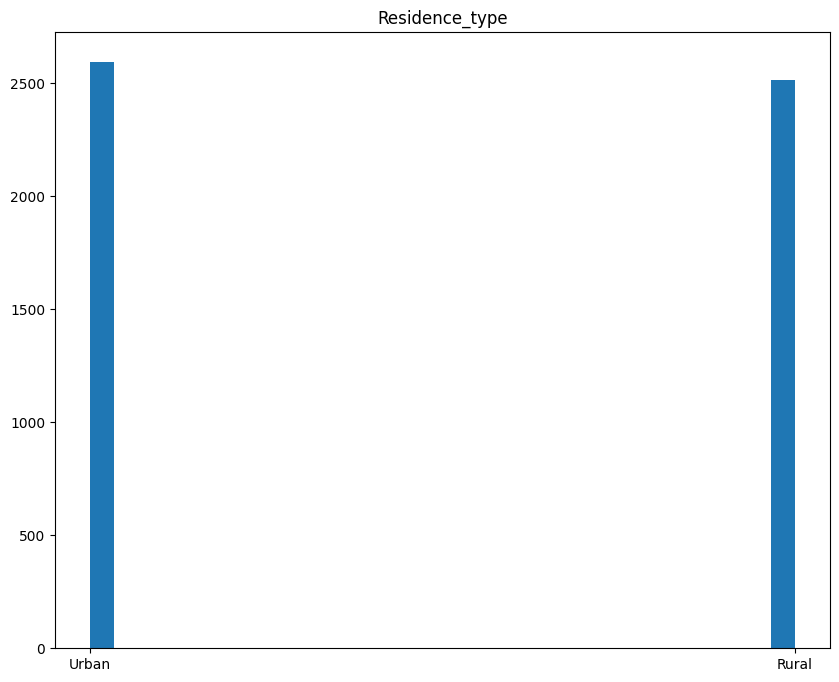

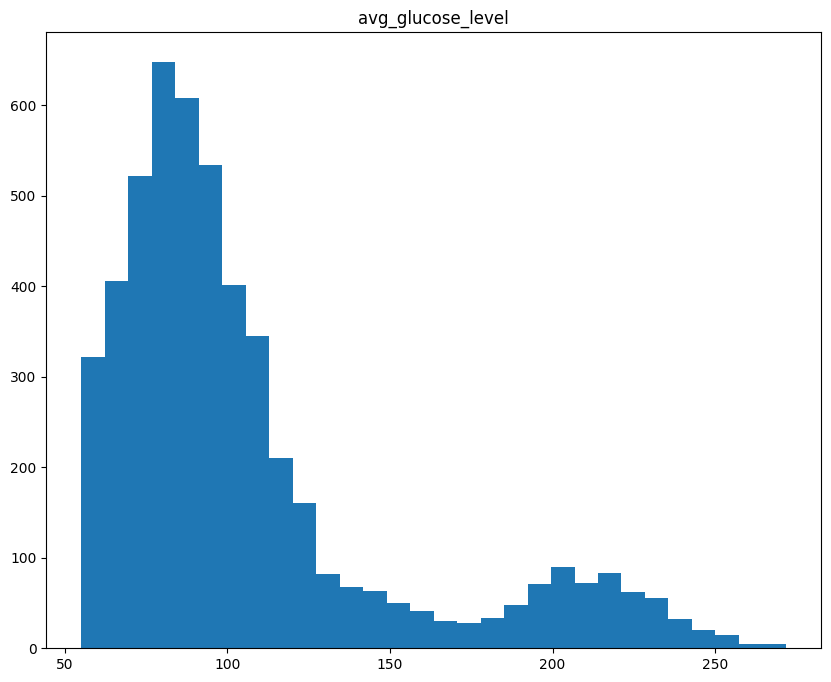

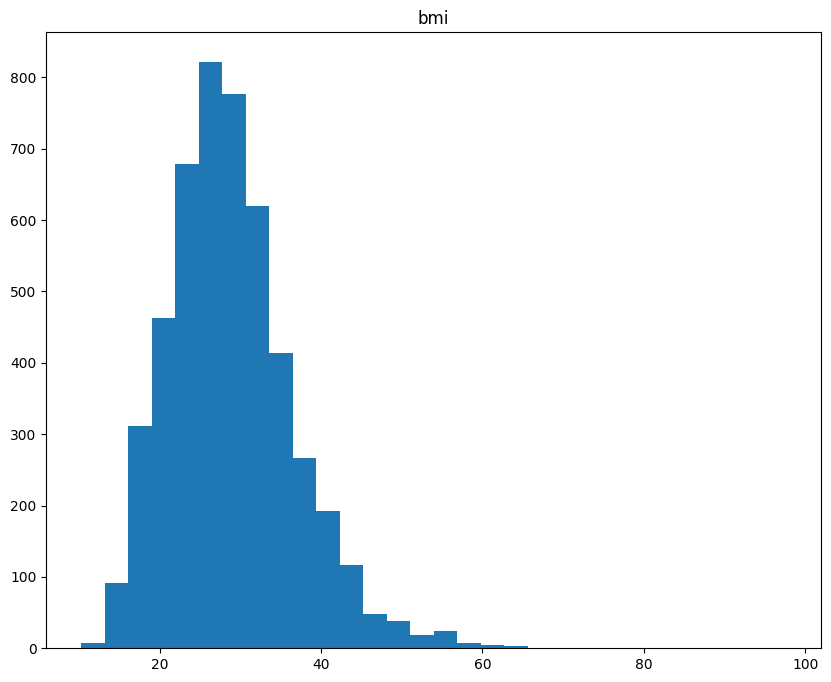

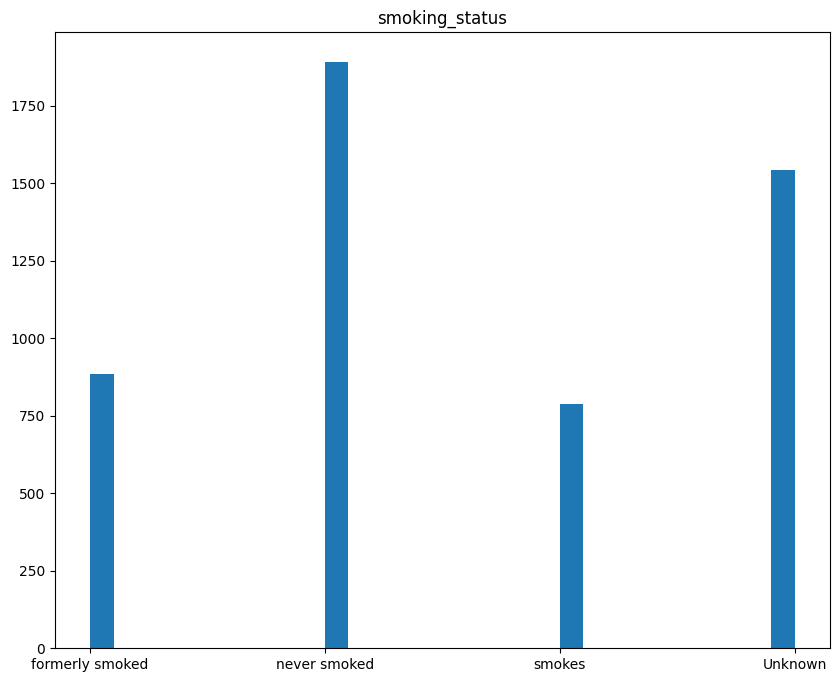

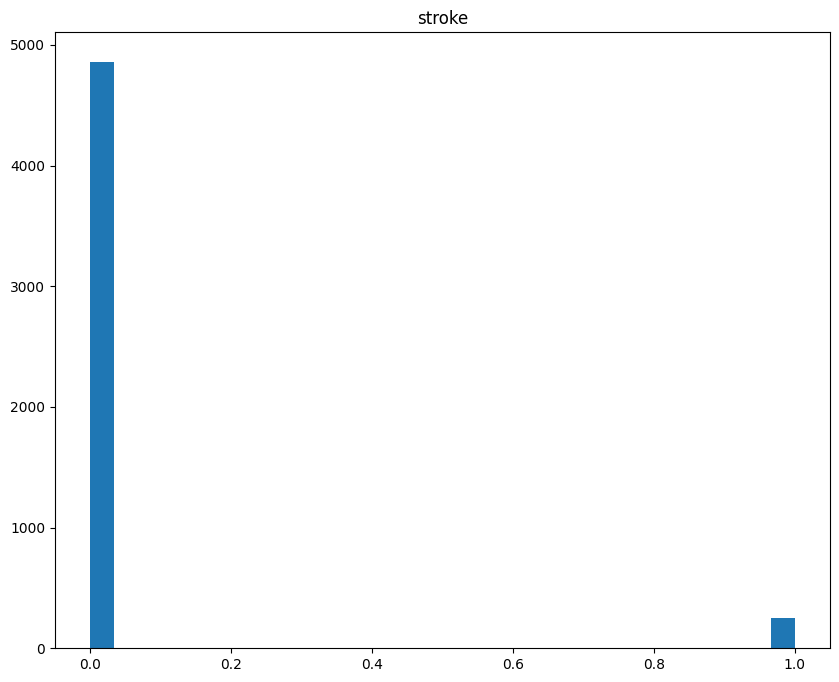

In [51]:
# plotting histogram for visual analysis - looking for gaussain distribution
for col in df.columns:
    fig, ax = plt.subplots(figsize=(10,8))
    ax.hist(df[col],bins=30)
    ax.set_title(col)


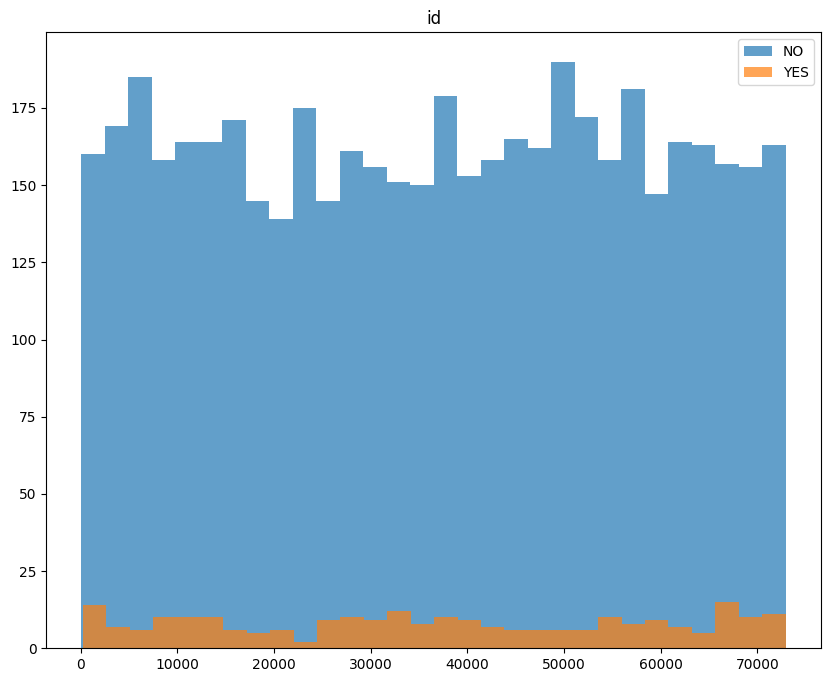

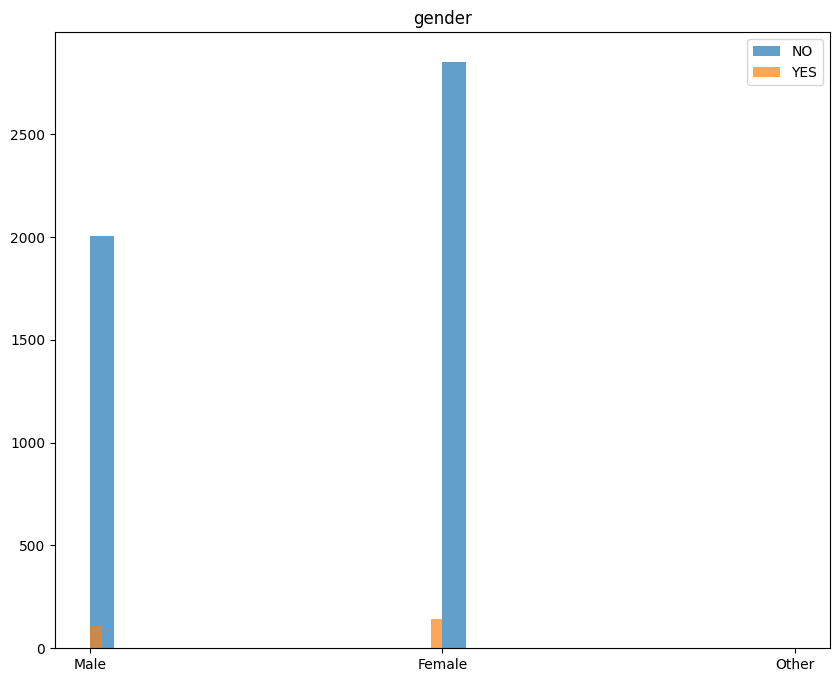

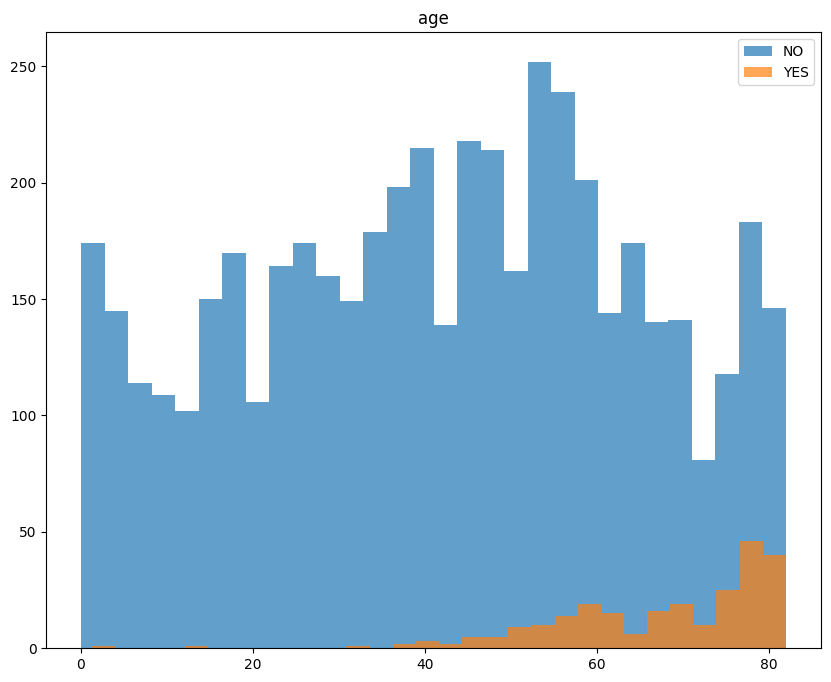

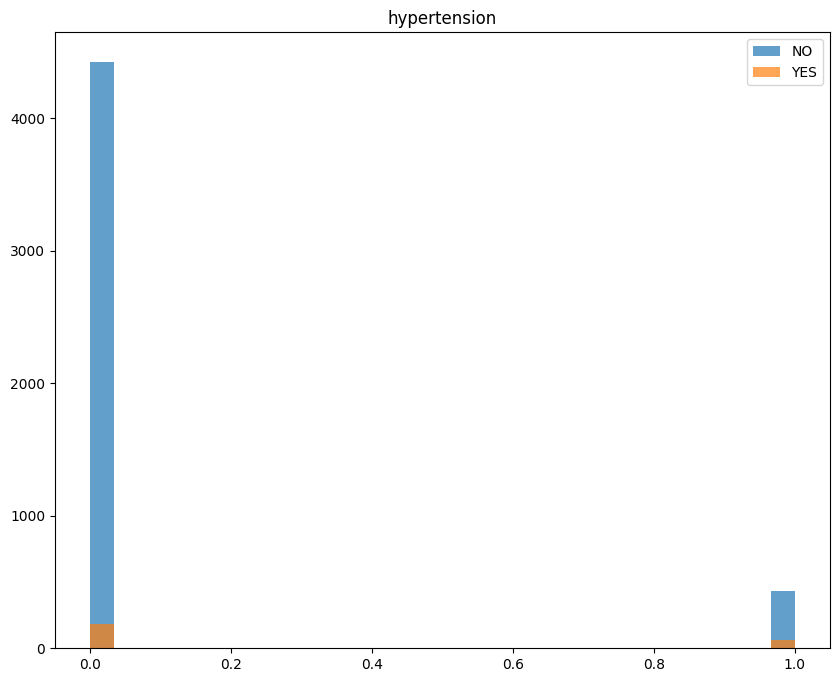

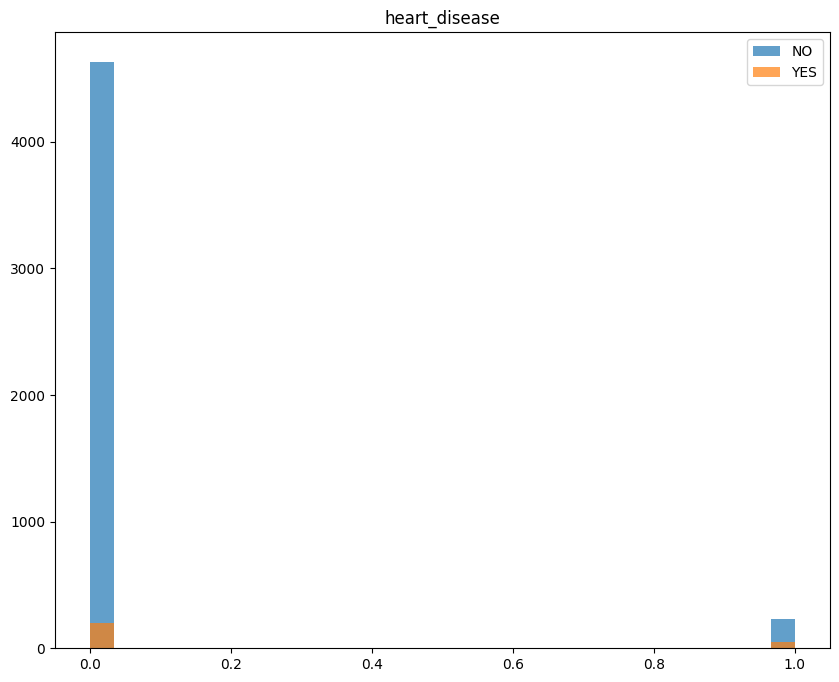

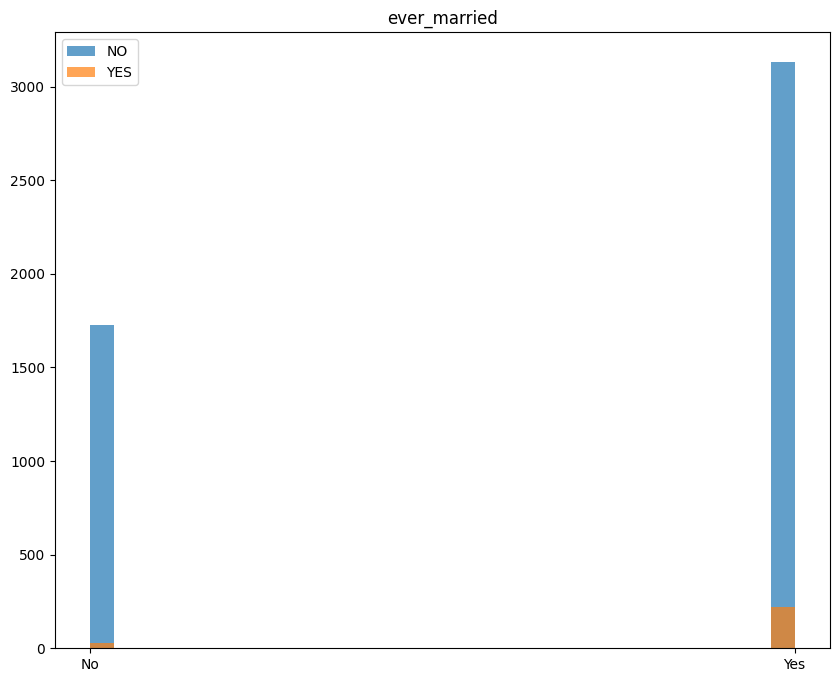

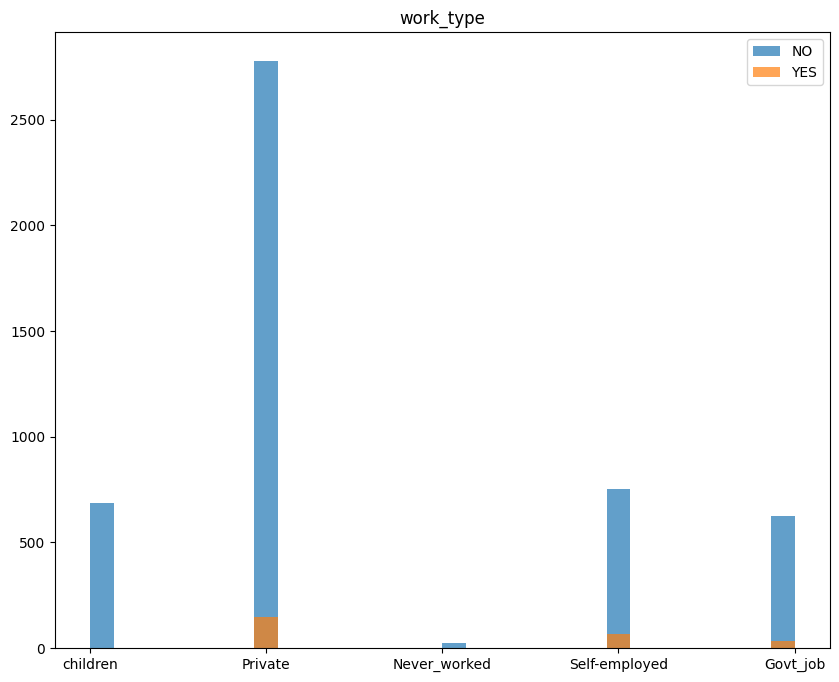

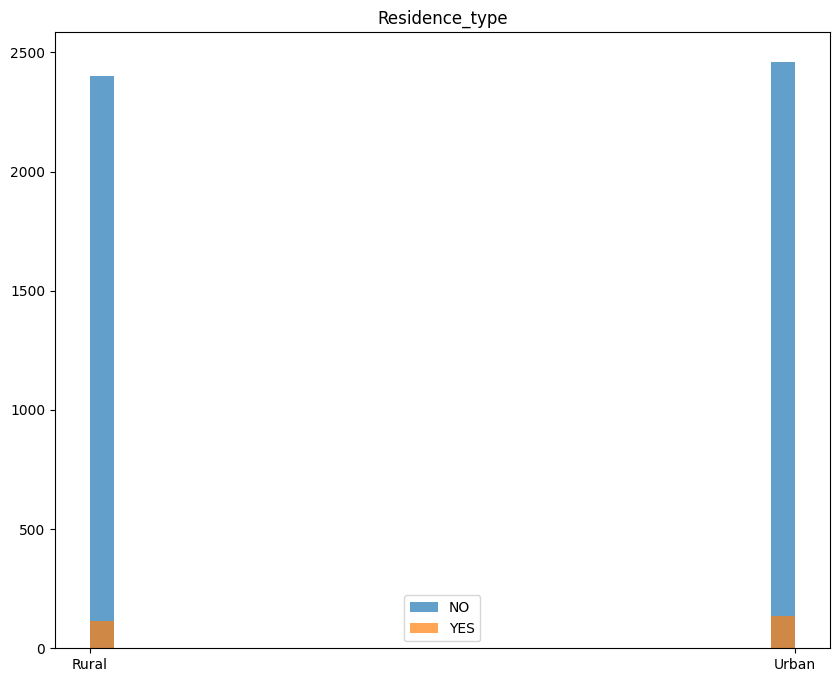

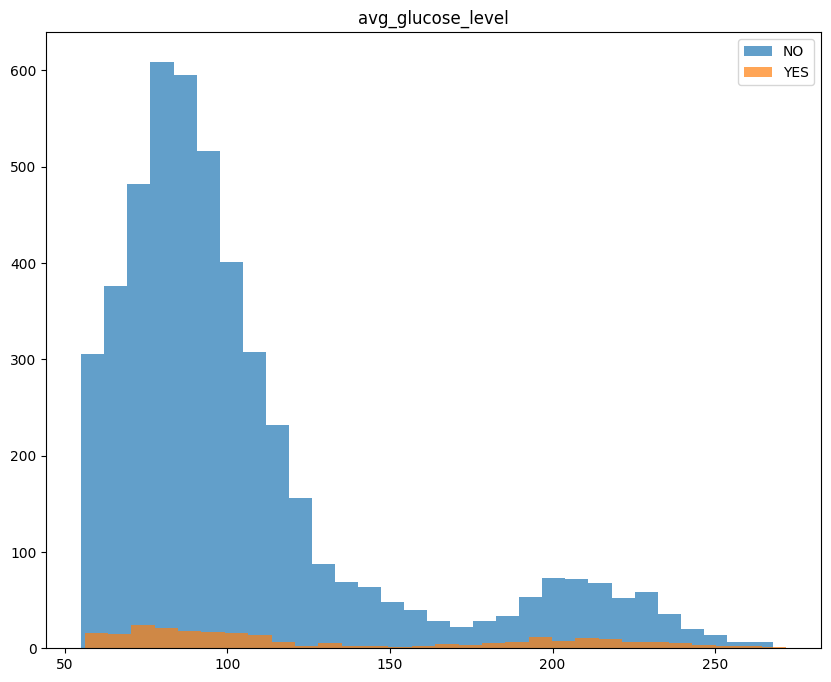

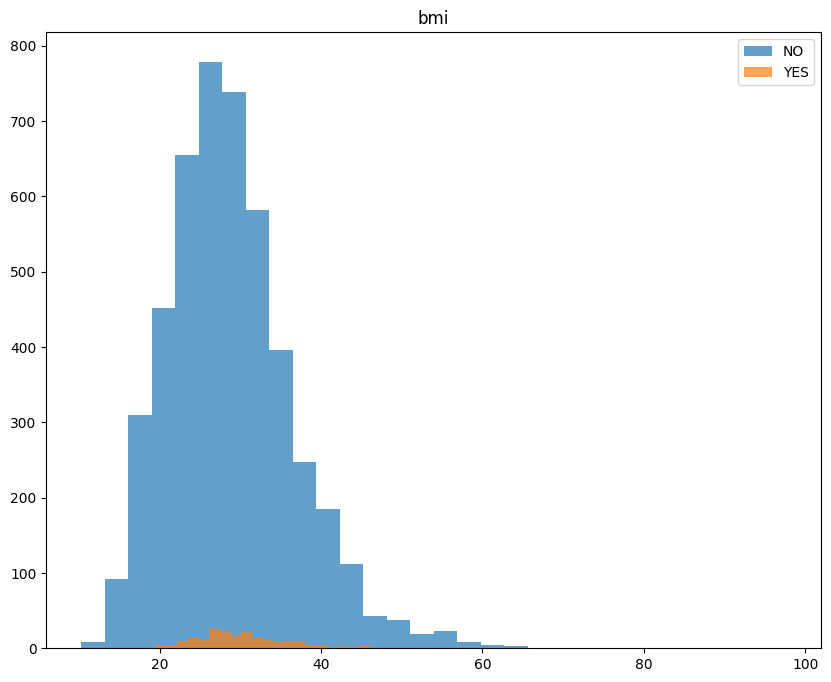

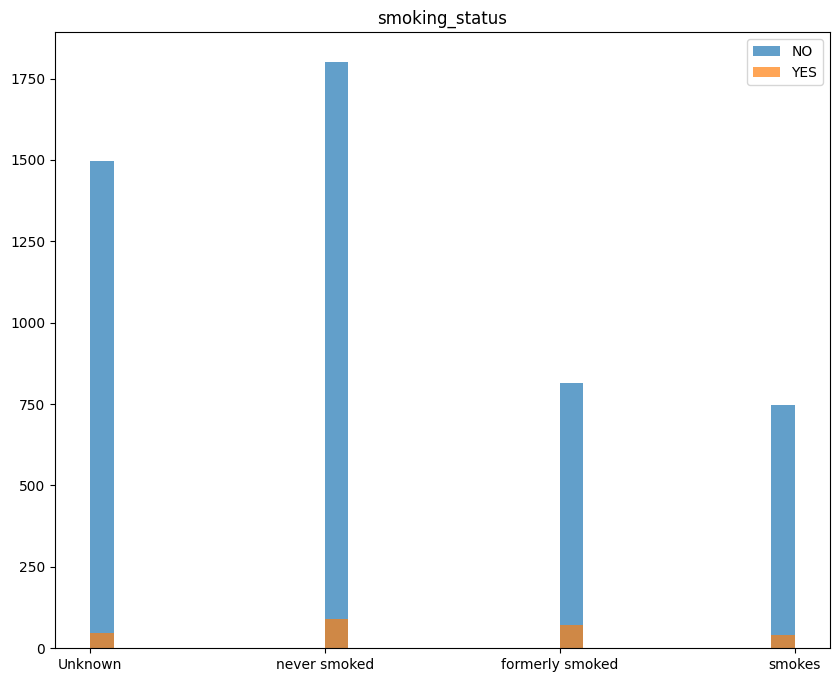

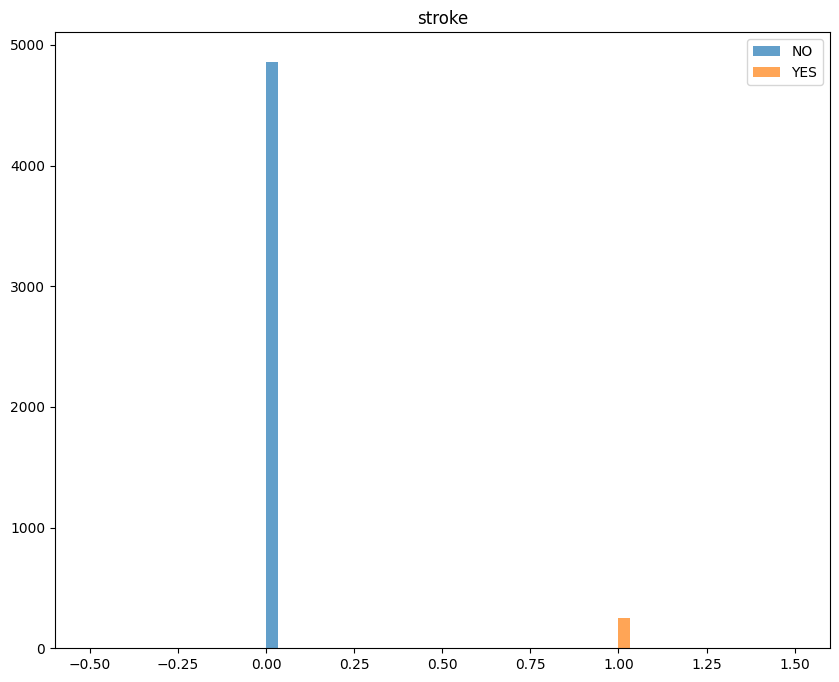

In [52]:
# histograms: stroke vs no-stroke
for col in df.columns:
    fig, ax = plt.subplots(figsize=(10,8))
    cl0 = df.loc[df["stroke"]==0,col]
    cl1 = df.loc[df["stroke"]==1,col]
    ax.hist(cl0,bins=30, alpha=0.7, label="NO", density=False)
    ax.hist(cl1,bins=30, alpha=0.7, label="YES", density=False)
    ax.legend()
    ax.set_title(col)

In [53]:
# retrieving gender values
df["gender"].unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [54]:
# changing categorical values to numerical data - label encoding
df["gender"].replace({"Male":0, "Female":1, "Other":2}, inplace=True)

C:\Users\jan.oleksiuk\AppData\Local\Temp\ipykernel_7716\790531309.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["gender"].replace({"Male":0, "Female":1, "Other":2}, inplace=True)
C:\Users\jan.oleksiuk\AppData\Local\Temp\ipykernel_7716\790531309.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', Tru

In [55]:
df.head(n=10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,0,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,1,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,0,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,1,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,1,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,0,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,0,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,1,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,1,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,1,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [56]:
df["work_type"].unique()

array(['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked'],
      dtype=object)

In [57]:
df["work_type"].replace({"Private":0, "Self-employed":1, "Govt_job":2, "children":3, "Never_worked":4}, inplace=True)

C:\Users\jan.oleksiuk\AppData\Local\Temp\ipykernel_7716\3839533851.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["work_type"].replace({"Private":0, "Self-employed":1, "Govt_job":2, "children":3, "Never_worked":4}, inplace=True)
C:\Users\jan.oleksiuk\AppData\Local\Temp\ipykernel_7716\3839533851.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set 

In [58]:
df.head(n=10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,0,67.0,0,1,Yes,0,Urban,228.69,36.6,formerly smoked,1
1,51676,1,61.0,0,0,Yes,1,Rural,202.21,NaN,never smoked,1
2,31112,0,80.0,0,1,Yes,0,Rural,105.92,32.5,never smoked,1
3,60182,1,49.0,0,0,Yes,0,Urban,171.23,34.4,smokes,1
4,1665,1,79.0,1,0,Yes,1,Rural,174.12,24.0,never smoked,1
5,56669,0,81.0,0,0,Yes,0,Urban,186.21,29.0,formerly smoked,1
6,53882,0,74.0,1,1,Yes,0,Rural,70.09,27.4,never smoked,1
7,10434,1,69.0,0,0,No,0,Urban,94.39,22.8,never smoked,1
8,27419,1,59.0,0,0,Yes,0,Rural,76.15,NaN,Unknown,1
9,60491,1,78.0,0,0,Yes,0,Urban,58.57,24.2,Unknown,1


In [59]:
df["Residence_type"].unique()

array(['Urban', 'Rural'], dtype=object)

In [60]:
df["Residence_type"].replace({"Urban":0, "Rural":1}, inplace=True)

C:\Users\jan.oleksiuk\AppData\Local\Temp\ipykernel_7716\2645124378.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Residence_type"].replace({"Urban":0, "Rural":1}, inplace=True)
C:\Users\jan.oleksiuk\AppData\Local\Temp\ipykernel_7716\2645124378.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True

In [61]:
df["smoking_status"].unique()

array(['formerly smoked', 'never smoked', 'smokes', 'Unknown'],
      dtype=object)

In [62]:
df["smoking_status"].replace({"Unknown":0, "formerly smoked":1, "never smoked":2, "smokes":3}, inplace=True)

C:\Users\jan.oleksiuk\AppData\Local\Temp\ipykernel_7716\2359376371.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["smoking_status"].replace({"Unknown":0, "formerly smoked":1, "never smoked":2, "smokes":3}, inplace=True)
C:\Users\jan.oleksiuk\AppData\Local\Temp\ipykernel_7716\2359376371.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_o

In [63]:
# deleting irrelevant id column 
df.drop(columns=["id"], inplace=True)

In [64]:
df.head(n=10)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,67.0,0,1,Yes,0,0,228.69,36.6,1,1
1,1,61.0,0,0,Yes,1,1,202.21,NaN,2,1
2,0,80.0,0,1,Yes,0,1,105.92,32.5,2,1
3,1,49.0,0,0,Yes,0,0,171.23,34.4,3,1
4,1,79.0,1,0,Yes,1,1,174.12,24.0,2,1
5,0,81.0,0,0,Yes,0,0,186.21,29.0,1,1
6,0,74.0,1,1,Yes,0,1,70.09,27.4,2,1
7,1,69.0,0,0,No,0,0,94.39,22.8,2,1
8,1,59.0,0,0,Yes,0,1,76.15,NaN,0,1
9,1,78.0,0,0,Yes,0,0,58.57,24.2,0,1


In [65]:
df["ever_married"].unique()

array(['Yes', 'No'], dtype=object)

In [66]:
df["ever_married"].replace({"No":0, "Yes":1}, inplace=True)

C:\Users\jan.oleksiuk\AppData\Local\Temp\ipykernel_7716\3301900434.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["ever_married"].replace({"No":0, "Yes":1}, inplace=True)
C:\Users\jan.oleksiuk\AppData\Local\Temp\ipykernel_7716\3301900434.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df

In [67]:
df.head(n=10)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,67.0,0,1,1,0,0,228.69,36.6,1,1
1,1,61.0,0,0,1,1,1,202.21,NaN,2,1
2,0,80.0,0,1,1,0,1,105.92,32.5,2,1
3,1,49.0,0,0,1,0,0,171.23,34.4,3,1
4,1,79.0,1,0,1,1,1,174.12,24.0,2,1
5,0,81.0,0,0,1,0,0,186.21,29.0,1,1
6,0,74.0,1,1,1,0,1,70.09,27.4,2,1
7,1,69.0,0,0,0,0,0,94.39,22.8,2,1
8,1,59.0,0,0,1,0,1,76.15,NaN,0,1
9,1,78.0,0,0,1,0,0,58.57,24.2,0,1


In [68]:
# searching NaN values
print(df.isna().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [69]:
# shifting NaN bmi values for mean BMI values
average_bmi = df["bmi"].mean()
df["bmi"] = df["bmi"].fillna(average_bmi)

In [70]:
df.head(n=10)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,67.0,0,1,1,0,0,228.69,36.600000,1,1
1,1,61.0,0,0,1,1,1,202.21,28.893237,2,1
2,0,80.0,0,1,1,0,1,105.92,32.500000,2,1
3,1,49.0,0,0,1,0,0,171.23,34.400000,3,1
4,1,79.0,1,0,1,1,1,174.12,24.000000,2,1
5,0,81.0,0,0,1,0,0,186.21,29.000000,1,1
6,0,74.0,1,1,1,0,1,70.09,27.400000,2,1
7,1,69.0,0,0,0,0,0,94.39,22.800000,2,1
8,1,59.0,0,0,1,0,1,76.15,28.893237,0,1
9,1,78.0,0,0,1,0,0,58.57,24.200000,0,1


Text(0.5, 1.0, 'bmi')

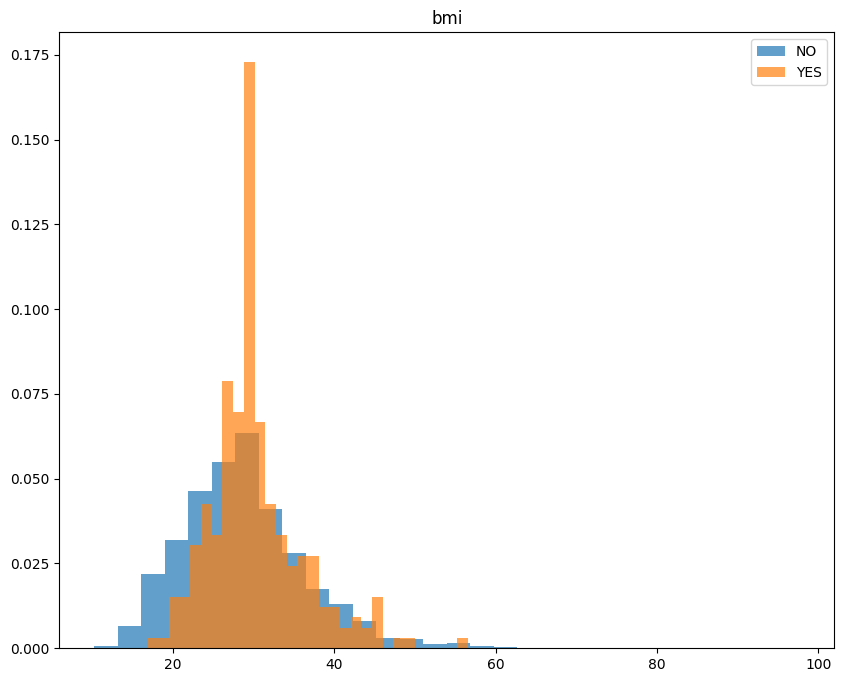

In [71]:
col = "bmi"
fig, ax = plt.subplots(figsize=(10,8))
cl0 = df.loc[df["stroke"]==0,col]
cl1 = df.loc[df["stroke"]==1,col]
ax.hist(cl0,bins=30, alpha=0.7, label="NO", density=True)
ax.hist(cl1,bins=30, alpha=0.7, label="YES", density=True)
ax.legend()
ax.set_title(col)

In [72]:
from sklearn.preprocessing import MinMaxScaler

In [73]:
# normalization of numerical data
scaler = MinMaxScaler()

feat_to_scale = ["age", "avg_glucose_level", "bmi"]
feat = scaler.fit_transform(df[feat_to_scale])

In [74]:
df.head(n=10)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,67.0,0,1,1,0,0,228.69,36.600000,1,1
1,1,61.0,0,0,1,1,1,202.21,28.893237,2,1
2,0,80.0,0,1,1,0,1,105.92,32.500000,2,1
3,1,49.0,0,0,1,0,0,171.23,34.400000,3,1
4,1,79.0,1,0,1,1,1,174.12,24.000000,2,1
5,0,81.0,0,0,1,0,0,186.21,29.000000,1,1
6,0,74.0,1,1,1,0,1,70.09,27.400000,2,1
7,1,69.0,0,0,0,0,0,94.39,22.800000,2,1
8,1,59.0,0,0,1,0,1,76.15,28.893237,0,1
9,1,78.0,0,0,1,0,0,58.57,24.200000,0,1


In [75]:
feat

array([[0.81689453, 0.80126489, 0.30126002],
       [0.74365234, 0.67902317, 0.21298095],
       [0.97558594, 0.23451205, 0.25429553],
       ...,
       [0.42626953, 0.12865848, 0.2325315 ],
       [0.62158203, 0.51320284, 0.17525773],
       [0.53613281, 0.13922999, 0.18213058]], shape=(5110, 3))

In [76]:
for i,col in enumerate(feat_to_scale):
    df[col] = feat[:,i]

In [77]:
df.head(n=10)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,0.816895,0,1,1,0,0,0.801265,0.301260,1,1
1,1,0.743652,0,0,1,1,1,0.679023,0.212981,2,1
2,0,0.975586,0,1,1,0,1,0.234512,0.254296,2,1
3,1,0.597168,0,0,1,0,0,0.536008,0.276060,3,1
4,1,0.963379,1,0,1,1,1,0.549349,0.156930,2,1
5,0,0.987793,0,0,1,0,0,0.605161,0.214204,1,1
6,0,0.902344,1,1,1,0,1,0.069107,0.195876,2,1
7,1,0.841309,0,0,0,0,0,0.181285,0.143184,2,1
8,1,0.719238,0,0,1,0,1,0.097082,0.212981,0,1
9,1,0.951172,0,0,1,0,0,0.015927,0.159221,0,1


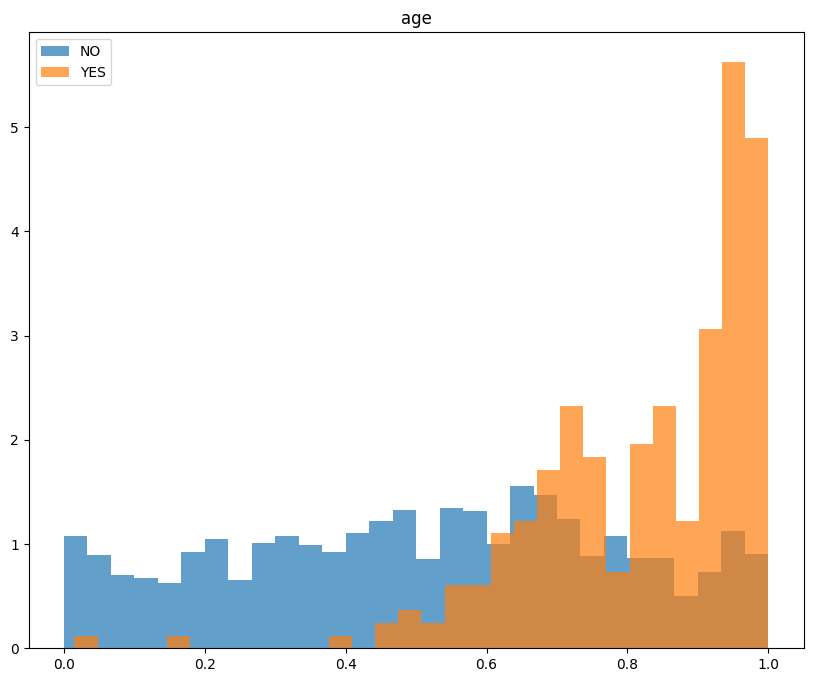

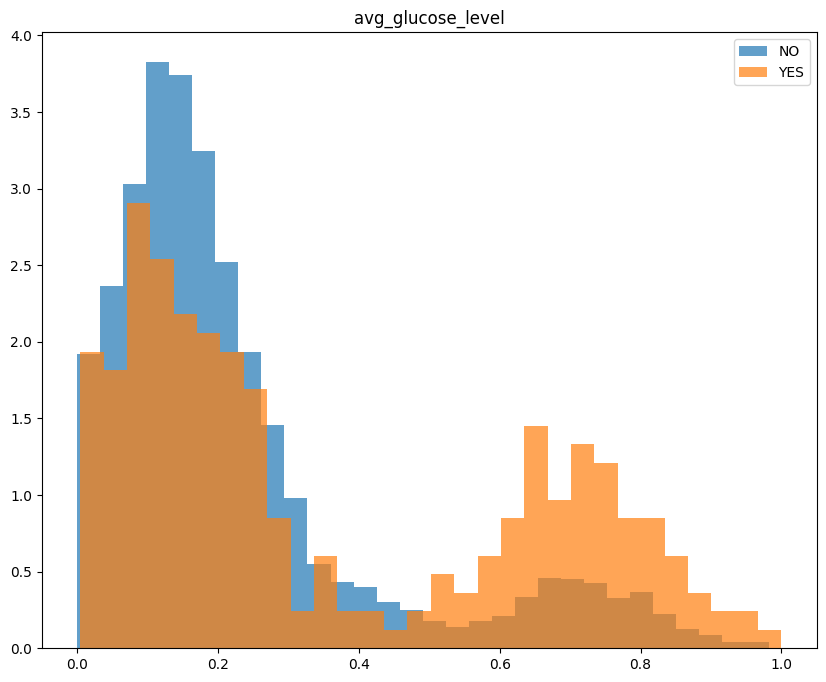

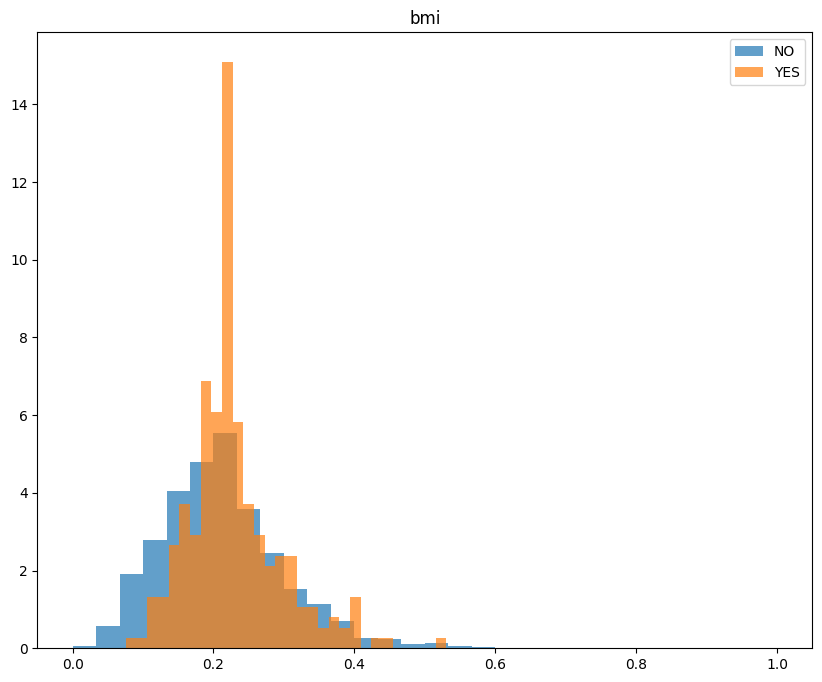

In [78]:
for col in feat_to_scale:
    fig, ax = plt.subplots(figsize=(10,8))
    cl0 = df.loc[df["stroke"]==0,col]
    cl1 = df.loc[df["stroke"]==1,col]
    ax.hist(cl0,bins=30, alpha=0.7, label="NO", density=True)
    ax.hist(cl1,bins=30, alpha=0.7, label="YES", density=True)
    ax.legend()
    ax.set_title(col)

In [79]:
from sklearn.model_selection import train_test_split


In [80]:
df.shape

(5110, 11)

In [81]:
# dividing dataset to dependent and idependent variables
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [82]:
X.shape

(5110, 10)

In [83]:
y.shape

(5110,)

In [ ]:
#First, perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

#UNDERSAMPLING - after splitting data to train-test set -> performed only on training data
X_train_df = pd.DataFrame(X_train) if not isinstance(X_train, pd.DataFrame) else X_train
y_train_df = pd.DataFrame(y_train, columns=['stroke']) if not isinstance(y_train, pd.DataFrame) else y_train

train_df = pd.concat([X_train_df.reset_index(drop=True), y_train_df.reset_index(drop=True)], axis=1)

df_positive = train_df[train_df['stroke'] == 1]
df_negative = train_df[train_df['stroke'] == 0]

df_negative_undersampled = df_negative.sample(n=int(1.02*len(df_positive)), random_state=42)

train_df_balanced = pd.concat([df_positive, df_negative_undersampled])
train_df_balanced = train_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

X_train = train_df_balanced.drop('stroke', axis=1)
y_train = train_df_balanced['stroke']

In [85]:
from sklearn.neighbors import KNeighborsClassifier

In [86]:
# 1st approach - using K-nn classifier
knn = KNeighborsClassifier(n_neighbors = 10)

In [87]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=10)

In [88]:
y_pred = knn.predict(X_test)

In [89]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [90]:
# results
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(f1_score(y_test, y_pred))

[[1124  333]
 [  35   41]]
0.7599478147423353
0.10962566844919786
0.5394736842105263
0.18222222222222223


In [91]:
from sklearn.svm import SVC

In [92]:
# 2nd approach - using SVM classifier with radial base functions as kernel
svm = SVC(kernel='rbf')

In [93]:
svm.fit(X_train, y_train)

SVC()

In [94]:
y_pred = svm.predict(X_test)

In [95]:
# evaluation
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(f1_score(y_test, y_pred))

[[1035  422]
 [  19   57]]
0.7123287671232876
0.11899791231732777
0.75
0.20540540540540542
